In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
import dask
dask.config.set({'dataframe.query-planning': False})
import spatialdata

c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap 

In [3]:
from insitupy.io import read_visium
from spatialdata_io import visium
from insitupy.datasets import xenium_human_breast_cancer, visium_human_breast_cancer

c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# xenium = xenium_human_breast_cancer()
# xenium.load_all()

In [5]:
# from insitupy.io import read_xenium
# p = r"C:\Users\ge37voy\.cache\InSituPy\demo_datasets\xenium_hbreastcancer\output-XETG00000__slide_id__hbreastcancer"
# x = read_xenium(p, backend="spatialdata")

In [6]:
from pathlib import Path
from insitupy import CACHE, InSituData

In [7]:
# prepare paths
data_dir = Path(CACHE / "out/demo_insitupy_project") # directory of xenium data
xenium = InSituData.read(data_dir)
xenium.load_all()

In [ ]:
xenium.show()

2025-12-02 13:11:22 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 2880x1694+801+405 (frame: 2902x1750+790+360) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2880x1570+801+405 (frame: 2902x1626+790+360) margins: 11, 45, 11, 11 minimum size: 385x499 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=600,805 maxtrack=0,0)


In [8]:
visium = visium_human_breast_cancer()

INFO: Reading Visium data with spatialdata-io...


H5 file exists. Checking md5sum...
The h5 file md5sum matches. Download is skipped. To force download set `overwrite=True`.
Spatial directory exists. Download is skipped. To force download set `overwrite=True`.
Visium data structure is ready at C:\Users\ge37voy\.cache\InSituPy\demo_datasets\visium_hbreastcancer\CytAssist_FFPE_Human_Breast_Cancer
Dataset contains:
- filtered_feature_bc_matrix.h5
- spatial/ directory


c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\anndata\_core\anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\anndata\_core\anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\spatialdata\models\models.py:1183: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)
INFO: Using 'visium' coordinate system for pixel size extraction.


Adding images...


INFO: Converting 4992 Point geometries with radius to circular polygons using buffer.


## Add fullres image to Visium dataset

The fullres image is the one that needs later to be aligned with Xenium data.

In [9]:
from insitupy.images.io import read_image

In [10]:
fullres_path = r"C:\Users\ge37voy\.cache\InSituPy\demo_datasets\visium_hbreastcancer\CytAssist_FFPE_Human_Breast_Cancer\fullres_image_file.ome.tif"
fullres, ome_meta, axes, pixel_size = read_image(fullres_path)

In [11]:
fullres_img = fullres[0]

In [12]:
visium.images.add_image(
    image=fullres_img,
    axes=axes,
    pixel_size=pixel_size,
    name="fullres")

In [13]:
visium.images['fullres']

dask.array<from-zarr, shape=(21571, 19505, 3), dtype=uint8, chunksize=(1024, 1024, 3), chunktype=numpy.ndarray>

In [14]:
visium_out = CACHE / "out/features_test_fullres"
visium.saveas(visium_out, overwrite=True)

Saving data to C:\Users\ge37voy\.cache\InSituPy\out\features_test_fullres


... storing 'feature_types' as categorical
... storing 'genome' as categorical


Saved.


In [15]:
from insitupy import InSituData

In [54]:
visium = InSituData.read(visium_out)
visium.load_all()

In [55]:
visium

InSituData
Method:		Visium
Slide ID:	slide_id
Sample ID:	sample_id
Path:		C:\Users\ge37voy\.cache\InSituPy\out\features_test_fullres

    ➤ images
       'fullres':   (21571, 19505, 3)
       'hires':     (2000, 1809, 3)
       'lowres':    (600, 543, 3)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

# Test transformation of images (not tested so far!)

In [56]:
source_pixel_size = visium.images.metadata["fullres"]["pixel_size"]
output_pixel_size = xenium.images.metadata["HE"]["pixel_size"]
output_size = (xenium.images.metadata["HE"]["shape"][0] * output_pixel_size,
               xenium.images.metadata["HE"]["shape"][1] * output_pixel_size)

M_file = r"C:\Users\ge37voy\.cache\InSituPy\demo_datasets\Visium_HE_alignment_files\matrix.csv"

visium._images = it = visium.images.transform(
    transformation_matrix=M_file,
    reference_pixel_size=output_pixel_size,
    output_size=output_size
)

visium._features = it = visium.features.transform(
    transformation_matrix=M_file,
    reference_pixel_size=output_pixel_size,
    source_pixel_size=source_pixel_size,
)

In [57]:
visium

InSituData
Method:		Visium
Slide ID:	slide_id
Sample ID:	sample_id
Path:		C:\Users\ge37voy\.cache\InSituPy\out\features_test_fullres

    ➤ images
       'fullres':   (10004, 13744, 3)
       'hires':     (927, 1274, 3)
       'lowres':    (278, 382, 3)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

In [58]:
visium.show()

2025-12-03 13:31:48 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 1629x983+504-330 (frame: 1651x1039+493-375) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2446x1477+507-316 (frame: 2468x1533+496-361) margins: 11, 45, 11, 11 minimum size: 385x500 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=600,806 maxtrack=0,0)
C:\Users\ge37voy\Github\InSituPy\insitupy\_core\_napari.py:183: UserWarning: The maximum value of the image is 0. Is the image really completely empty?
  warn("The maximum value of the image is 0. Is the image really completely empty?")
C:\Users\ge37voy\Github\InSituPy\insitupy\_core\_napari.py:183: UserWarning: The maximum value of the image is 0. Is the image really completely empty?
  warn("The maximum value of the image is 0. Is the image really completely empty?")


In [42]:
output_size

(5477.825, 7525.9)

In [43]:
visium.show()

C:\Users\ge37voy\Github\InSituPy\insitupy\_core\_napari.py:183: UserWarning: The maximum value of the image is 0. Is the image really completely empty?
  warn("The maximum value of the image is 0. Is the image really completely empty?")
C:\Users\ge37voy\Github\InSituPy\insitupy\_core\_napari.py:183: UserWarning: The maximum value of the image is 0. Is the image really completely empty?
  warn("The maximum value of the image is 0. Is the image really completely empty?")


In [49]:
import matplotlib.pyplot as plt

In [60]:
visium.images['hires'][0]

dask.array<array, shape=(927, 1274, 3), dtype=uint8, chunksize=(927, 1274, 3), chunktype=numpy.ndarray>

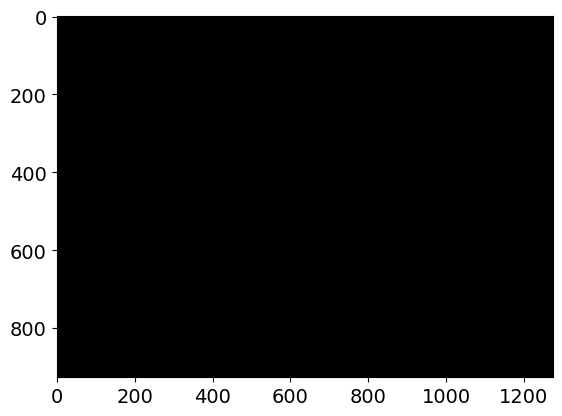

In [59]:
plt.imshow(visium.images['hires'][0])

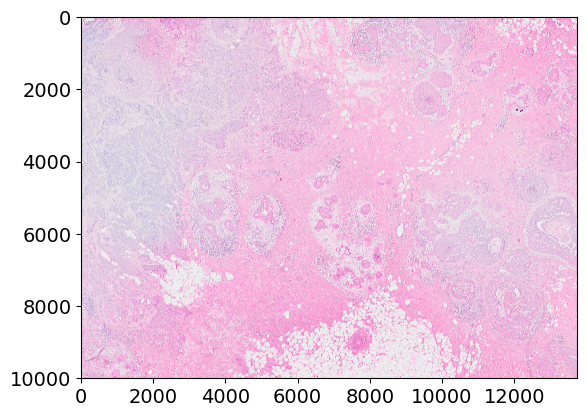

In [ ]:
plt.imshow(visium.images['fullres'][0])

In [52]:
visium.show()

C:\Users\ge37voy\Github\InSituPy\insitupy\_core\_napari.py:183: UserWarning: The maximum value of the image is 0. Is the image really completely empty?
  warn("The maximum value of the image is 0. Is the image really completely empty?")
C:\Users\ge37voy\Github\InSituPy\insitupy\_core\_napari.py:183: UserWarning: The maximum value of the image is 0. Is the image really completely empty?
  warn("The maximum value of the image is 0. Is the image really completely empty?")


In [20]:

visium._features = it = visium.features.transform(
    transformation_matrix=M_file,
    reference_pixel_size=xenium.images.metadata["HE"]["pixel_size"]
)


In [21]:
visium

InSituData
Method:		Visium
Slide ID:	slide_id
Sample ID:	sample_id
Path:		C:\Users\ge37voy\.cache\InSituPy\out\features_test_fullres

    ➤ images
       'fullres':   (21571, 19505, 3)
       'hires':     (2000, 1809, 3)
       'lowres':    (600, 543, 3)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

In [ ]:
vt

InSituData
Method:		Visium
Slide ID:	slide_id
Sample ID:	sample_id
Path:		None

    ➤ images
       'hires':    (2000, 1809, 3)
       'lowres':   (600, 543, 3)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

In [28]:
from insitupy.tools.registration import ImageRegistration
from insitupy.images.io import read_image

In [46]:
fullres_path = r"C:\Users\ge37voy\.cache\InSituPy\demo_datasets\visium_hbreastcancer\CytAssist_FFPE_Human_Breast_Cancer\fullres_image_file.ome.tif"
fullres_pyramid, ome_meta, axes, pixel_size = read_image(fullres_path)
fullres_image = fullres_pyramid[0]

In [47]:
fullres_image

dask.array<from-zarr, shape=(21571, 19505, 3), dtype=uint8, chunksize=(1024, 1024, 3), chunktype=numpy.ndarray>

In [50]:
visium.images.metadata

{'hires': {'filename': 'hires.zarr',
  'shape': (2000, 1809, 3),
  'axes': 'YXS',
  'OME': {},
  'pixel_size': 5.906139790390711,
  'rgb': True},
 'lowres': {'filename': 'lowres.zarr',
  'shape': (600, 543, 3),
  'axes': 'YXS',
  'OME': {},
  'pixel_size': 19.687132776192747,
  'rgb': True}}

In [62]:
imreg = ImageRegistration(
    image=fullres_image,
    template=visium.images["hires"][0],
    axes_image="YXS",
    axes_template=visium.images.metadata["hires"]["axes"],
    max_width=4000,
    deconvolve_image=True,
    deconvolve_template=True
)

In [63]:
imreg.run()

		Load image into memory...
		Load template into memory...
		Run color deconvolution on image...
		Run color deconvolution on template...
		Rescale image and template to save memory.
			Rescaled from (21570, 19505) to following dimensions: (4206, 3803)
			Rescaled from (2000, 1805) to following dimensions: (4210, 3799)
		Convert scaled images to 8 bit
		2025-12-02 16:56:20: Get features...
			Adjust contrast with clip method...
			Method: SIFT...
		2025-12-02 16:56:26: Compute matches...
		2025-12-02 16:56:31: Filter matches...
			Sufficient number of good matches found (92/20).
		2025-12-02 16:56:31: Display matches...
		2025-12-02 16:56:32: Fetch keypoints...
		2025-12-02 16:56:32: Estimate 2D affine transformation matrix...
		2025-12-02 16:56:32: Register image by affine transformation...


In [53]:
imreg.image

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(21570, 19505), dtype=uint8)

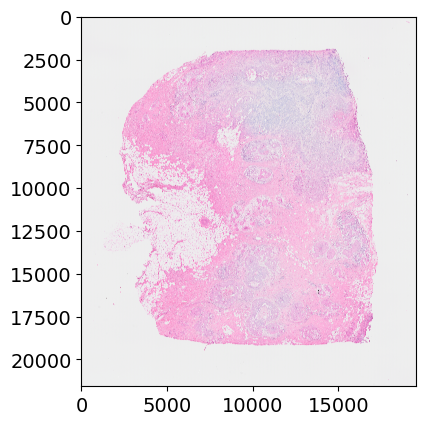

In [58]:
plt.imshow(fullres_image)

In [59]:
imreg.registered.shape

(2000, 1805)

In [65]:
fullres_image

dask.array<from-zarr, shape=(21571, 19505, 3), dtype=uint8, chunksize=(1024, 1024, 3), chunktype=numpy.ndarray>

# The fullres image is already registered! It just needs to be added with the right pixel size!

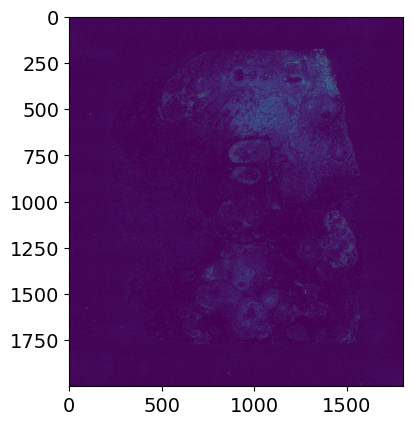

In [57]:
plt.imshow(imreg.registered, vmax=10)

In [64]:
imreg.save_qc(output_dir=CACHE / "out/registration_test",
           identifier="fullres_to_visium_hires"
           )

		Save QC files to C:\Users\ge37voy\.cache\InSituPy\out\registration_test\registration_qc


In [11]:
M_file = r"C:\Users\ge37voy\.cache\InSituPy\demo_datasets\Visium_HE_alignment_files\matrix.csv"
vt = visium.copy()
vt._features = vt.features.transform(
    transformation_matrix=M_file
    )

# Test transformation of images (not tested so far!)

In [13]:
it = vt.images.transform(
    transformation_matrix=M_file
)

In [15]:
vt

InSituData
Method:		Visium
Slide ID:	slide_id
Sample ID:	sample_id
Path:		None

    ➤ images
       'hires':    (2000, 1809, 3)
       'lowres':   (600, 543, 3)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

In [14]:
it

'hires':    (2000, 1809, 3)
'lowres':   (600, 543, 3)

In [16]:
import matplotlib.pyplot as plt

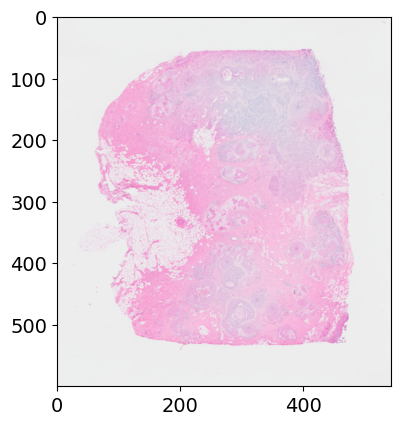

In [26]:
plt.imshow(vt.images["lowres"][0].compute(), vmax=10)

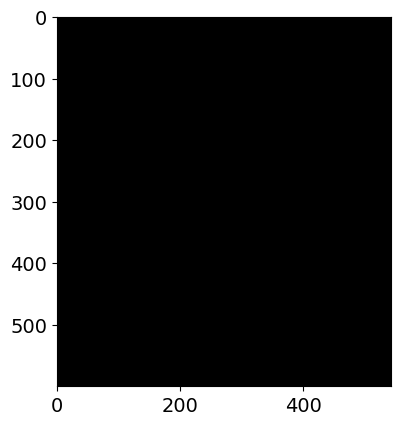

In [ ]:
plt.imshow(it["lowres"][0].compute(), vmax=10)

In [23]:
it["lowres"][0]

dask.array<array, shape=(600, 543, 3), dtype=uint8, chunksize=(600, 543, 3), chunktype=numpy.ndarray>

In [20]:
visium

InSituData
Method:		Visium
Slide ID:	slide_id
Sample ID:	sample_id
Path:		C:\Users\ge37voy\.cache\InSituPy\out\features_test

    ➤ images
       'hires':    (2000, 1809, 3)
       'lowres':   (600, 543, 3)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

In [18]:
vt

InSituData
Method:		Visium
Slide ID:	slide_id
Sample ID:	sample_id
Path:		None

    ➤ images
       'hires':    (2000, 1809, 3)
       'lowres':   (600, 543, 3)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

In [21]:
vt.show()

In [14]:
ft

FeatureData (Type: 'feature')
    .data: 4992 obs × 18085 vars
    .shapes: 4992 geometries

AttributeError: 'FeatureData' object has no attribute 'show'

In [21]:
xenium

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\demo_datasets\xenium_hbreastcancer\output-XETG00000__slide_id__hbreastcancer

    ➤ images
       'nuclei':   (25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 167780 × 313
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
               var: 'gene_ids', 'feature_types', 'genome'
               obsm: 'spatial'
           boundaries
               BoundariesData object with 2 entries:
                   cells
                   nuclei
    ➤ transcripts
       DataFrame with shape Delayed('int-8301f3c0-0854-4c5e-a77d-b042aaccf0fc') x 8

In [20]:
visium.features.shapes

,geometry,radius
AACACCTACTATCGAA-1,POINT (4131 4636),63.917904
AACACGTGCATCGCAC-1,POINT (13355 16640),63.917904
AACACTTGGCAAGGAA-1,POINT (8845 12067),63.917904
AACAGGAAGAGCATAG-1,POINT (14716 15518),63.917904
AACAGGATTCATAGTT-1,POINT (11404 12365),63.917904
...,...,...
TGTTGGAACGAGGTCA-1,POINT (8731 9049),63.917904
TGTTGGAAGCTCGGTA-1,POINT (6598 4776),63.917904
TGTTGGATGGACTTCT-1,POINT (10447 6653),63.917904
TGTTGGCCAGACCTAC-1,POINT (11039 12368),63.917904


In [22]:
ft.pixel_size

np.float64(2.592434801179086)

In [19]:
ft.shapes

,geometry,radius
AACACCTACTATCGAA-1,POINT (282.309 30141.997),63.917904
AACACGTGCATCGCAC-1,POINT (32685.887 8000.404),63.917904
AACACTTGGCAAGGAA-1,POINT (20197.666 19013.591),63.917904
AACAGGAAGAGCATAG-1,POINT (29978.279 4315.518),63.917904
AACAGGATTCATAGTT-1,POINT (21338.638 12432.899),63.917904
...,...,...
TGTTGGAACGAGGTCA-1,POINT (12369.385 18872.743),63.917904
TGTTGGAAGCTCGGTA-1,POINT (1001.024 23776.617),63.917904
TGTTGGATGGACTTCT-1,POINT (6415.422 14084.953),63.917904
TGTTGGCCAGACCTAC-1,POINT (21293.682 13378.101),63.917904


In [4]:
from spatialdata_io import visium

vp = r"C:\Users\ge37voy\.cache\InSituPy\demo_datasets\visium_hbreastcancer\CytAssist_FFPE_Human_Breast_Cancer"
vis = visium(vp, dataset_id="bc")

c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\anndata\_core\anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\anndata\_core\anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\ge37voy\AppData\Local\miniconda3\envs\sd313\Lib\site-packages\spatialdata\models\models.py:1183: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


In [5]:
vis

SpatialData object
├── Images
│     ├── 'bc_hires_image': DataArray[cyx] (3, 2000, 1809)
│     └── 'bc_lowres_image': DataArray[cyx] (3, 600, 543)
├── Shapes
│     └── 'bc': GeoDataFrame shape: (4992, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (4992, 18085)
with coordinate systems:
    ▸ 'bc', with elements:
        bc_hires_image (Images), bc_lowres_image (Images), bc (Shapes)
    ▸ 'bc_downscaled_hires', with elements:
        bc_hires_image (Images), bc (Shapes)
    ▸ 'bc_downscaled_lowres', with elements:
        bc_lowres_image (Images), bc (Shapes)

In [6]:
from insitupy.spatialdata.convert import convert_from_spatialdata

In [7]:
dataset_id = "bc"
sample_id = "test_id"
# Convert to InSituData format
data = convert_from_spatialdata(
    sdata=vis,
    image_keys={
        "hires": f"{dataset_id}_hires_image",
        "lowres": f"{dataset_id}_lowres_image"
    },
    features_key=dataset_id,
    cells_key=None,  # No cells available in Visium data
    table_key="table",
    cell_boundaries_key=None,  # Visium uses spots, not boundaries
    nucleus_boundaries_key=None,
    transcripts_key=None,  # Visium doesn't have single-molecule transcripts
    slide_id=dataset_id if dataset_id else "visium_slide",
    sample_id=sample_id if sample_id else "visium_sample",
    method_name="Visium",
)

INFO: Using 'bc' coordinate system for pixel size extraction.


Extracted pixel size 1.0 from 'bc'
Adding images...


In [8]:
data

InSituData
Method:		Visium
Slide ID:	bc
Sample ID:	test_id
Path:		None

    ➤ images
       'hires':    (3, 2000, 1809)
       'lowres':   (3, 600, 543)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

In [9]:
from insitupy import CACHE

In [10]:
feature_path = CACHE / "out" / "features_test"
data.saveas(feature_path, overwrite=True)

Saving data to C:\Users\ge37voy\.cache\InSituPy\out\features_test


... storing 'feature_types' as categorical
... storing 'genome' as categorical


Saved.


In [13]:
from insitupy import InSituData

In [14]:
vr = InSituData.read(feature_path)

In [16]:
vr.load_all()

In [17]:
vr

InSituData
Method:		Visium
Slide ID:	bc
Sample ID:	test_id
Path:		C:\Users\ge37voy\.cache\InSituPy\out\features_test

    ➤ images
       'hires':    (3, 2000, 1809)
       'lowres':   (3, 600, 543)
    ➤ features
       FeatureData (Type: 'feature')
           .data: 4992 obs × 18085 vars
           .shapes: 4992 geometries

In [20]:
for elem_type, key, elem in vis.gen_elements():
    print(key)

bc_hires_image
bc_lowres_image
bc
table


In [ ]:
xdconv = convert_from_spatialdata(
    sdata=sdata,
    image_keys={
        "nuclei": "morphology_mip",
        "mip": "morphology_focus"
    },
    cells_key="cell_circles",
    table_key="table",
    cell_boundaries_key="cell_labels",
    nucleus_boundaries_key="nucleus_labels",
    transcripts_key="transcripts",
    slide_id="slide_test",
    sample_id="sample_test",
    method_name="Xenium"
)